In [1]:
import pandas as pd  # manipulation de données tabulaires
import numpy as np   # calcul numérique

import matplotlib.pyplot as plt  # visualisation
import seaborn as sns            # visualisation avancée

from sklearn.preprocessing import MinMaxScaler  # normalisation
from sklearn.metrics.pairwise import cosine_similarity  # similarité

In [2]:
df = pd.read_csv("../data/spotify.csv")

df.head() # afficher premières lignes

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info() #Donne un résumé global du datase

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
df.describe() #Donne des statistiques sur les colonnes numériques

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
df = df.dropna()

In [6]:
df["artists"].fillna("Unknown", inplace=True)

C:\Users\oa121\AppData\Local\Temp\ipykernel_19772\2776879040.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["artists"].fillna("Unknown", inplace=True)


In [7]:
df.isnull().sum() # vérifier valeurs nulles

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [8]:
cols = [
    "track_name",
    "artists",
    "track_genre",
    
    "danceability",
    "energy",
    "valence",
    "tempo",
    "acousticness",
    "instrumentalness",
    
    "loudness",        # important pour perception sonore
    "speechiness",     # utile (rap vs musique)
    
    "popularity"
]

df = df[cols]

In [9]:
df.duplicated().sum()

7052

In [10]:
df = df.drop_duplicates()

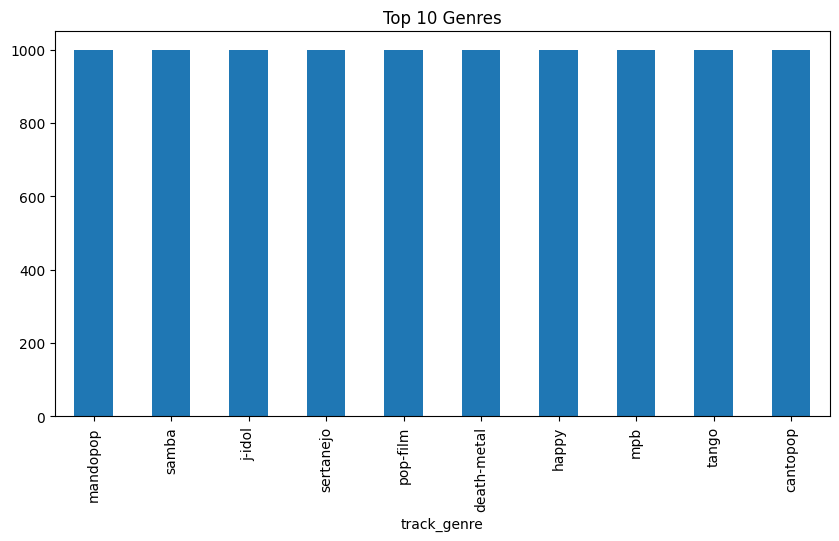

In [11]:
plt.figure(figsize=(10,5))  # taille du graphique
df["track_genre"].value_counts().head(10).plot(kind="bar")  # top genres
plt.title("Top 10 Genres")
plt.show()

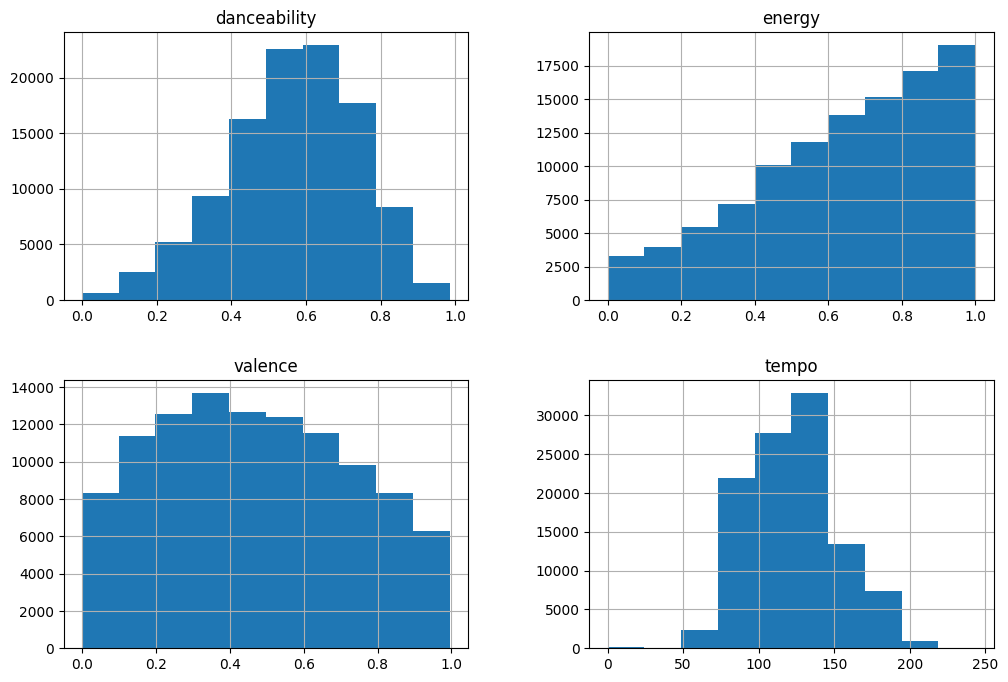

In [12]:
features_visu = ["danceability", "energy", "valence", "tempo"] #DISTrubution des features

df[features_visu].hist(figsize=(12,8))  # histogrammes
plt.show()

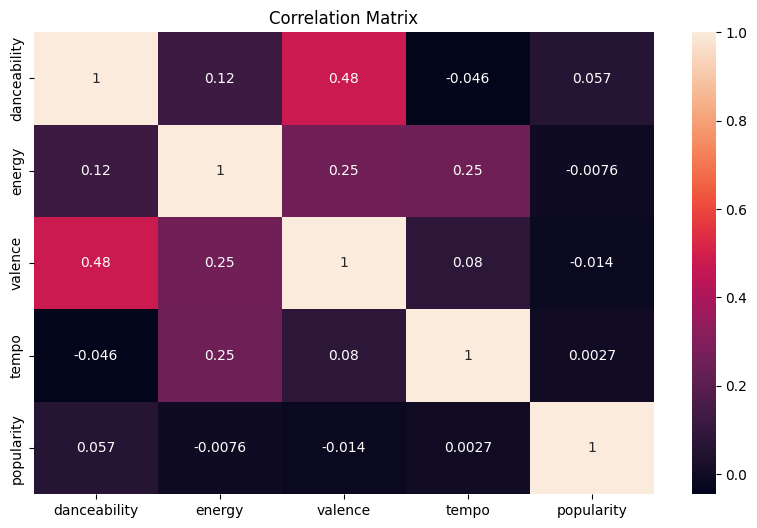

In [13]:
#correlation
plt.figure(figsize=(10,6))

sns.heatmap(
    df[features_visu + ["popularity"]].corr(),  # matrice corrélation
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [14]:
# Séparer features et infos
info_cols = ["track_name", "artists", "track_genre"]  # infos texte

feature_cols = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "acousticness",
    "instrumentalness",
    "loudness",
    "speechiness",
    "popularity"
]  # features numériques

In [15]:
scaler = MinMaxScaler()  # initialiser scaler
df_scaled = df.copy()  # copie du dataset

df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])  
# normaliser entre 0 et 1

In [16]:
def recommend(song_name, df, feature_cols, top_n=5):
    
    # ici je récupérer index de la musique
    idx = df[df["track_name"] == song_name].index[0]
    
    # puis vecteur de la musique choisie
    song_vector = df.iloc[idx][feature_cols].values.reshape(1, -1)
    
    # puis je  calcul similarité avec toutes les autres
    similarities = cosine_similarity(song_vector, df[feature_cols])[0]
    
    # trier résultats
    similar_indices = similarities.argsort()[::-1][1:top_n+1]
    
    # retourner recommandations
    return df.iloc[similar_indices][["track_name", "artists", "track_genre"]]

In [17]:
recommend("Blinding Lights", df_scaled, feature_cols)

,track_name,artists,track_genre
28270,Good on You,Krewella;Nucleya,dub
29230,Good on You,Krewella;Nucleya,dubstep
29104,Good On You,Krewella;Nucleya,dubstep
28103,Good On You,Krewella;Nucleya,dub
32738,Chodź Chodź Chodź - Remix,Rosalie.;Jan-Rapowanie,electronic


In [18]:
sample_df = df_scaled.sample(50, random_state=42)
sample_features = sample_df[feature_cols]  # features numériques

similarity_matrix = cosine_similarity(sample_features)  # matrice 50x50



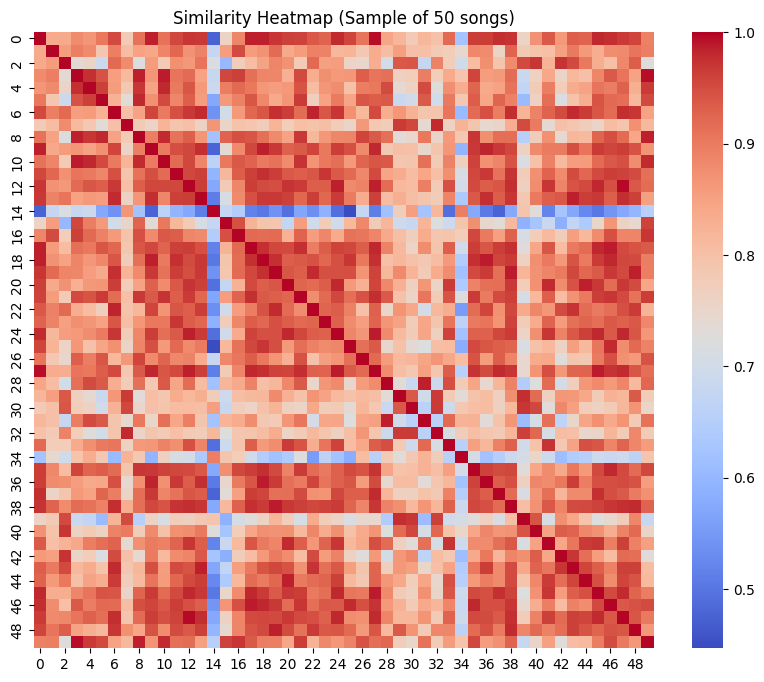

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    cmap="coolwarm"
)

plt.title("Similarity Heatmap (Sample of 50 songs)")
plt.show()

In [20]:
from sklearn.decomposition import PCA  # réduction dimension
pca = PCA(n_components=2)  # 2D

reduced = pca.fit_transform(df_scaled[feature_cols])
# projection des musiques en 2d


In [21]:
reduced.shape

(106947, 2)

In [22]:
print("Nombre de musiques :", df_scaled.shape[0])

Nombre de musiques : 106947


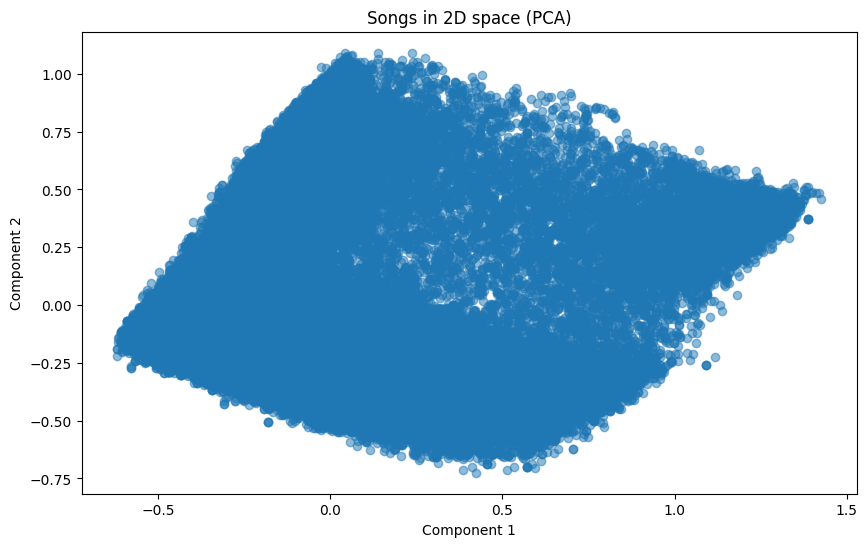

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(reduced[:,0], reduced[:,1], alpha=0.5)

plt.title("Songs in 2D space (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

In [24]:
def search_song(df, keyword):
    return df[df["track_name"].str.contains(keyword, case=False, na=False)]